In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

%matplotlib inline

In [2]:
import numpy as np
import networkx as nx

from sqw import (build_walk_operator, build_gate_list,
                 run_walk_numpy, run_walk_quimb, visualise_circuit)

In [3]:
G = nx.Graph()
for u, v, w in [('v1','v2',1), ('v2','v3',1), ('v2','v4',1), ('v3','v4',1)]:
    G.add_edge(u, v, weight=w)

layout = build_gate_list(G)
print('qubits (one per directed edge):', layout['num_qubits'])
print('gates per step:', len(layout['gates']))

qubits (one per directed edge): 8
gates per step: 54


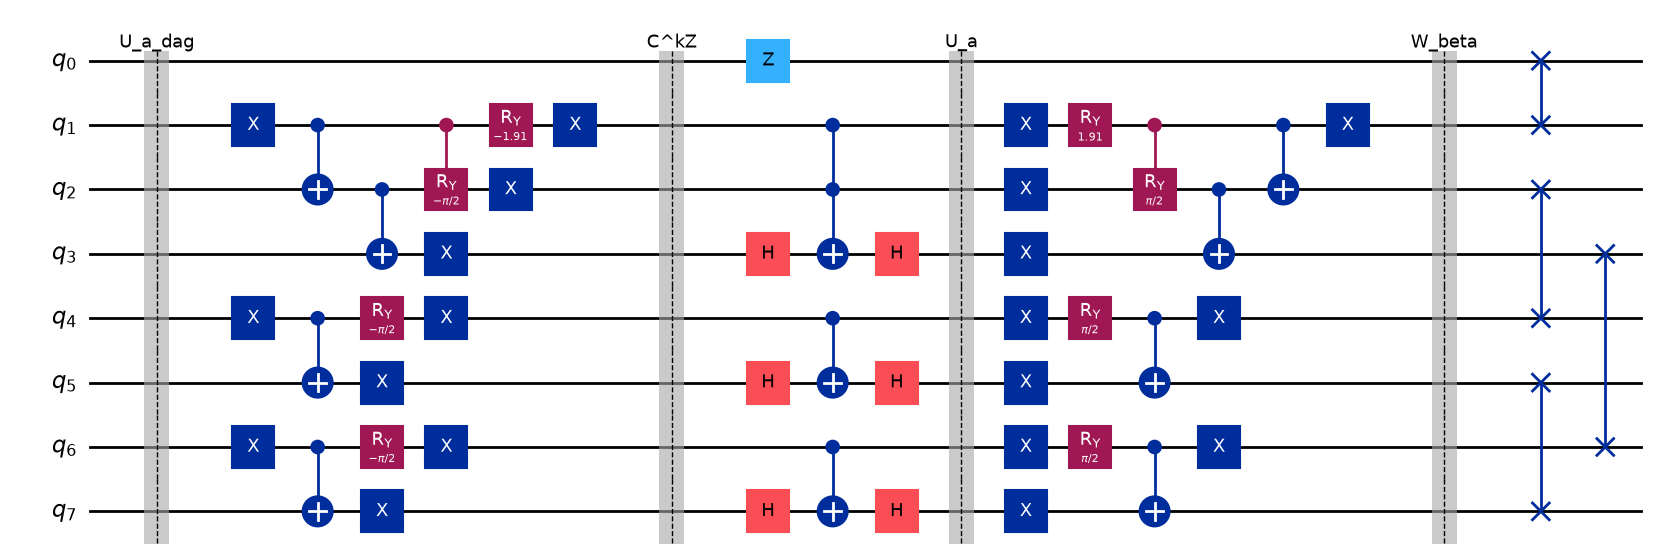

In [4]:
_ = visualise_circuit(G, output='mpl')

In [5]:
res = build_walk_operator(G)
ni, nl, cm = res['node_index'], res['node_list'], res['clique_map']

psi0 = np.zeros(len(nl), dtype=complex)
for e in [('v2','v1'), ('v2','v3'), ('v2','v4')]:
    psi0[ni[e]] = 1/np.sqrt(3)
final_np, _ = run_walk_numpy(res['W'], cm, ni, psi0, steps=10, plot_cliques=False)

init = {e: 1/np.sqrt(3) for e in [('v2','v1'), ('v2','v3'), ('v2','v4')]}
final_q, _ = run_walk_quimb(layout['gates'], layout['num_qubits'],
                            layout['index_of'], cm, init, steps=10,
                            plot_cliques=False)

final_q_vec = np.array([final_q[n] for n in nl])
print('max |numpy - quimb| after 10 steps:', np.abs(final_np - final_q_vec).max())

max |numpy - quimb| after 10 steps: 4.6351811278100286e-15
